Note the comments in the code below are relative to the first edition of the book

There is a difference between the output here and figure3.2a for the
 book.  This code uses system 3.26, while the figure in the book
includes the triangle correction mentioned following system 3.26.


The code for the complete graph runs quite slowly.  There are very many equations.
0.03
lumped
I[-1] 66.11545727490768
0
individual based
pair based
0.02
lumped
I[-1] 46.372354998172575
0
individual based
pair based
0.01
lumped
I[-1] 5.801742052754238
0
individual based
pair based
tau = 1
lumped
[1.11859767e-03 1.22979932e-06 2.26783312e-08 1.04396315e-08
 6.88455208e-09 5.22802578e-09 4.29185407e-09 3.70362944e-09
 3.31149941e-09 3.04436500e-09 2.86781811e-09 2.76869377e-09
 2.75117888e-09 2.84020200e-09 3.09276411e-09 3.62156670e-09
 4.64028599e-09 6.54832980e-09 1.00881388e-08 1.66355178e-08
 2.87323591e-08 5.10566193e-08 9.21700964e-08 1.67624189e-07
 3.05379901e-07 5.55052570e-07 1.00323957e-06 1.79807049e-06
 3.18692011e-06 5.57148395e-06 9.58335331e-06 1.61797777e-05
 2.67523598e-

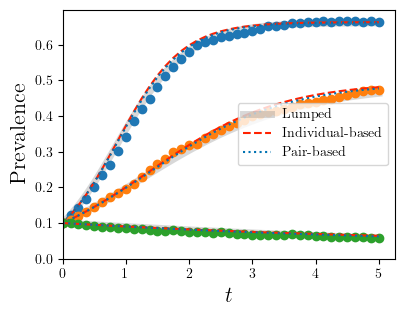

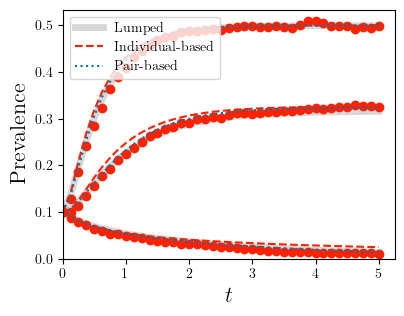

In [4]:
import EoN
import networkx as nx
from matplotlib import rc
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy import integrate

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'


#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


'''
Code to generate figure 3.2 from page 94.  This is a bit messy because
we have to define the lumped ODE models.  Since python deals with ODEs by
taking 1D arrays we have to set up all the variables into a single long vector.

This uses the same lumped model as for fig 2.11.

'''
print("There is a difference between the output here and figure3.2a for the\n",
    "book.  This code uses system 3.26, while the figure in the book\n"
    "includes the triangle correction mentioned following system 3.26.\n\n")

print("The code for the complete graph runs quite slowly.  There are very many equations.")


def star(N):
    G = nx.Graph()
    G.add_node(0)
    for node_id in range(1,N):
        G.add_edge(0,node_id)
    return G




def complete_graph_dX(X, t, tau, gamma, N):
    r'''This system is given in Proposition 2.3, taking Q=S, T=I
    f_{SI}(k) = f_{QT}= k*\tau
    f_{IS}(k) = f_{TQ} = \gamma

    \dot{Y}^0 = \gamma Y^1 - 0\\
    \dot{Y}^1 = 2\gamma Y^2  + 0Y^0 - (\gamma + (N-1)\tau)Y^1
    \dot{Y}^2 = 3\gamma Y^3 + (N-1)\tau Y^1 - (2\gamma+2(N-2))Y^2
    ...
    \dot{Y}^N = (N-1)\tau Y^{N-1} - N\gamma Y^N
    Note that X has length N+1
    '''
    #X[k] is probability of k infections.
    dX = []
    dX.append(gamma*X[1])
    for k in range(1,N):
        dX.append((k+1)*gamma*X[k+1]+ (N-k+1)*(k-1)*tau*X[k-1]
                    - ((N-k)*k*tau + k*gamma)*X[k])
    dX.append((N-1)*tau*X[N-1] - N*gamma*X[N])

    return np.array(dX)

def complete_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount):
    times = np.linspace(tmin, tmax, tcount)
    X0 = np.zeros(N+1)  #length N+1 of just 0 entries
    X0[I0]=1. #start with 100 infected.
    X = integrate.odeint(complete_graph_dX, X0, times, args = (tau, gamma, N))
    #X[t] is array whose kth entry is p(k infected| time=t).
    I = np.array([sum(k*Pkt[k] for k in range(len(Pkt))) for Pkt in X])
    S = N-I
    return times, S, I


def star_graph_dX(X, t, tau, gamma, N):
    '''this system is given in Proposition 2.4, taking Q=S, T=I
    so f_{SI}(k) = f_{QT}(k) = k*tau
    f_{IS}(k) = f_{TQ}(k) = gamma
    X has length 2*(N-1)+2 = 2N'''

    #    [[central node infected] + [central node susceptible]]
    #X = [Y_1^1, Y_1^2, ..., Y_1^{N}, Y_2^0, Y_2^1, ..., Y_2^{N-1}]

    #Note that in proposition Y^0 is same as Y_2^0
    #and Y^N is same as Y_1^N

    #Y1[k]: central node infected, & k-1 peripheral nodes infected
    Y1vec = [0]+list(X[0:N])      #for Y_1^k, use Y1vec[k]
    #pad with 0 to make easier calculations Y_1^0=0
    #the probability of -1 nodes infected is 0

    #Y2[k]: central node susceptible & k peripheral nodes infected
    Y2vec = list(X[N:])+[0]   #for Y_2^k use Y2vec[k]
    #padded with 0 to make easier calculations. Y_2^N=0
    #the probability of N (of N-1) peripheral nodes infected is 0
    dY1vec = []
    dY2vec = []
    for k in range(1, N):
        #k-1 peripheral nodes infected, central infected
        dY1vec.append((N-k+1)*tau*Y1vec[k-1] + (k-1)*tau*Y2vec[k-1]
                    +k*gamma*Y1vec[k+1]
                    - ((N-k)*tau + (k-1)*gamma+gamma)*Y1vec[k])
    #now the Y^N equation
    dY1vec.append(tau*Y1vec[N-1] + (N-1)*tau*Y2vec[N-1] - N*gamma*Y1vec[N])

    #now the Y^0 equation
    dY2vec.append(gamma*(N-1)*Y1vec[1] + gamma*Y2vec[1]-0)

    for k in range(1,N):
        #k peripheral nodes infected, central susceptible
        dY2vec.append(0 + gamma*Y1vec[k+1] + gamma*(k+1)*Y2vec[k+1]
                    - (k*tau + 0 + k*gamma)*Y2vec[k])

    return np.array(dY1vec + dY2vec)

def star_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount):
    times = np.linspace(tmin, tmax, tcount)
    #    [[central node infected] + [central node susceptible]]
    #X = [Y_1^1, Y_1^2, ..., Y_1^{N}, Y_2^0, Y_2^1, ..., Y_2^{N-1}]
    X0 = np.zeros(2*N)  #length 2*N of just 0 entries
    #X0[I0]=I0*1./N #central infected, + I0-1 periph infected prob
    X0[N+I0] = 1#-I0*1./N #central suscept + I0 periph infected
    X = EoN.analytic._my_odeint_(star_graph_dX, X0, times, args = (tau, gamma, N))
    #X looks like [[central susceptible,k periph] [ central inf, k-1 periph]] x T

    central_susc = X[:,N:]
    central_inf = X[:,:N]
    print(central_susc[-1][:])
    print(central_inf[-1][:])
    I = np.array([ sum(k*central_susc[t][k] for k in range(N))
            + sum((k+1)*central_inf[t][k] for k in range(N))
            for t in range(len(X))])
    S = N-I
    return times, S, I




N=100#000
I0 = 10
gamma = 1
tmin = 0
tmax = 5
tcount = 41
report_times = np.linspace(0,tmax, tcount) #for simulations

iterations = 100

plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)

taus1 = [0.03, 0.02, 0.01]
taus2 = [1, 0.5, 0.1]

plt.figure(0)

G = nx.complete_graph(N)

for tau in taus1:

    print(tau)
    print('lumped')
    t, S, I = complete_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount)
    plt.plot(t, I/N, color = 'grey', linewidth=5, alpha=0.3, label = 'Lumped')

    print('I[-1]', I[-1])
    initial_infecteds=random.sample(range(N), I0)

    obs_I = 0*report_times
    for counter in range(iterations):
        if counter%100==0:
            print(counter)
        IC = random.sample(range(N),I0)
        t, S, I = EoN.fast_SIS(G, tau, gamma, initial_infecteds = initial_infecteds, tmax = tmax)
        obs_I += EoN.subsample(report_times, t, I)
    plt.plot(report_times, obs_I*1./(iterations*N), 'o')
    #print(obs_I[-1]/iterations)
    print('individual based')
    t, S, I = EoN.SIS_individual_based_pure_IC(G, tau, gamma, initial_infecteds, tmax=tmax, tcount = tcount)
    plt.plot(t, I/N, '--', color = colorI, label = 'Individual-based')

    print('pair based')
    t, S, I = EoN.SIS_pair_based_pure_IC(G, tau, gamma, initial_infecteds, tmax=tmax, tcount = tcount)
    plt.plot(t, I/N, ':', color = colorI2, label = 'Pair-based')

    if tau == 0.03:
        plt.legend()

plt.xlabel('$t$', fontsize=16)
plt.ylabel('Prevalence', fontsize=16)
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.savefig('fig3p2a.png', dpi=900)

plt.figure(1)
G = star(N)
for tau in taus2:
    print('tau = {}'.format(tau))
    print('lumped')
    t, S, I = star_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount)
    print(I)
    plt.plot(t, I/N, color = 'grey', linewidth=5, alpha=0.3, label = 'Lumped')

    initial_infecteds=random.sample(range(1,N), I0)#not central node 0

    obs_I = 0*report_times
    for counter in range(iterations):
        if counter%100==0:
            print(counter)
        IC = random.sample(range(N),I0)
        t, S, I = EoN.fast_SIS(G, tau, gamma, initial_infecteds = initial_infecteds, tmax = tmax)
        obs_I += EoN.subsample(report_times, t, I)
    #print(obs_I/iterations)
    plt.plot(report_times, obs_I*1./(iterations*N), 'o', color=colorI)

    print('individual based')
    t, S, I = EoN.SIS_individual_based_pure_IC(G, tau, gamma, initial_infecteds, tmax=tmax, tcount = tcount)
    plt.plot(t, I/N, '--', color = colorI, label = 'Individual-based')

    print('pair based')
    t, S, I = EoN.SIS_pair_based_pure_IC(G, tau, gamma, initial_infecteds, tmax=tmax, tcount = tcount)
    plt.plot(t, I/N, ':', color = colorI2, label = 'Pair-based')

    if tau == 1:
        plt.legend()
plt.xlabel('$t$', fontsize=16)
plt.ylabel('Prevalence', fontsize=16)
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.savefig('fig3p2b.png',  dpi=900)

# Figure 3.3

In [5]:
import networkx as nx
import EoN
from matplotlib import rc
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'


#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)



def run_and_plot(G, tau, gamma, initial_infecteds, main, inset, tmax, numits=1):
    N = G.order()
    I_all = []  # Store all report_Is arrays
    report_times = np.linspace(0,tmax,501)
    for counter in range(numits):
        if counter%100==0:
            print(counter)
        t, S, I = EoN.fast_SIS(G, tau, gamma, initial_infecteds = initial_infecteds, tmax = tmax)
        I = EoN.subsample(report_times, t, I)
        I_all.append(I)
    I_mean = np.mean(I_all, axis=0)
    main.plot(report_times, I_mean/N, color='grey', linewidth=5, alpha=0.3, label = 'Stochastic Simulation')
    if inset is not None:
        inset.plot(report_times, I_mean/N, color='grey', linewidth=5, alpha=0.3, label = 'Stochastic Simulation')
    
    t, S, I = EoN.SIS_individual_based_pure_IC(G, tau, gamma, initial_infecteds= initial_infecteds, tmax = tmax, tcount = 501)
    main.plot(t, I/N, '--', color = colorI, label = 'Individual-based')
    if inset is not None:
        inset.plot(t, I/N, '--', color = colorI, label = 'Individual-based')
    
    t, S, I = EoN.SIS_pair_based_pure_IC(G, tau, gamma, initial_infecteds = initial_infecteds, tmax=tmax, tcount=501)
    main.plot(t, I/N, ':', color = colorI2, label = 'Pair-based')
    if inset is not None: 
        inset.plot(t, I/N, ':', color = colorI2, label = 'Pair-based')

    if inset is not None:
        main.indicate_inset_zoom(inset, edgecolor="black")

    plt.xlabel('$t$', fontsize=16)

    plt.ylabel('Prevalence', fontsize=16)


0
100
200
300
400
500
600
700
800
900
line done


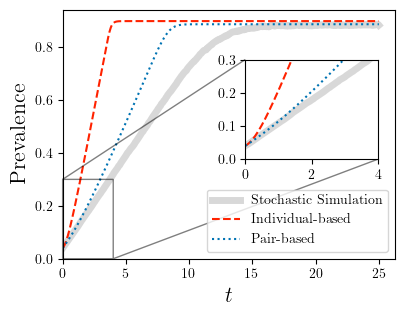

In [6]:



fig=plt.figure(0, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = main.inset_axes(
                [.55, 0.4, 0.4, 0.4],
                xlim=(0, 4), ylim=(0, 0.3))

N=100
linegraph = nx.path_graph(N)

tau = 5
gamma = 1

tmax=25

initial = int(N/2)
initial_infecteds = [initial+i for i in [-2, -1, 0, 1]]

numits=1000
run_and_plot(linegraph, tau, gamma, initial_infecteds, main, inset, tmax, numits)
plt.legend()
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.savefig('fig3p3a.png', dpi=900)
print('line done')


# tmax = 25

# report_times = np.linspace(0,tmax,1001)
# for counter in range(1):
#     t, S, I = EoN.fast_SIS(lattice, tau, gamma, initial_infecteds = initial_infecteds, tmax = tmax)
#     I = EoN.subsample(report_times, t, I)
#     I_all.append(I)
# I_mean = np.mean(I_all, axis=0)
# main.plot(report_times, I_mean/N, color='grey', linewidth=3, label = 'Stochastic Simulation')
# inset.plot(report_times, I_mean/N, color='grey', linewidth=3, label = 'Stochastic Simulation')
# t, S, I = EoN.SIS_pair_based_pure_IC(lattice, tau, gamma, initial_infecteds = initial_infecteds, tmax=tmax, tcount=1001)
# main.plot(t, I/N, color = 'k', label = 'Pair-based')
# inset.plot(t, I/N, color = 'k', label = 'Pair-based')
# t, S, I = EoN.SIS_individual_based_pure_IC(lattice, tau, gamma, initial_infecteds= initial_infecteds, tmax = tmax, tcount = 1001)
# main.plot(t, I/N, '--', color = 'b', label = 'Individual-based')
# inset.plot(t, I/N, '--', color = 'b', label = 'Individual-based')


# plt.xlabel('$t$')

# plt.ylabel('Prevalence')
# plt.legend()
# plt.savefig('fig3p3b.png', dpi=900)




0
100
200
300
400
500
600
700
800
900
lattice done


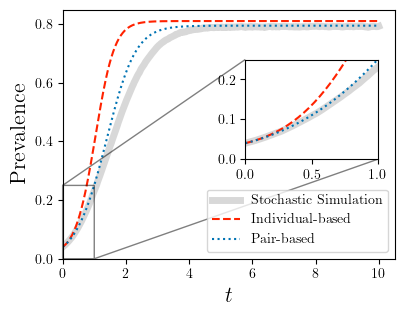

In [7]:
gamma = 1
tmax=10
tau = 1.5
L=10
numits = 1000
lattice = nx.grid_2d_graph(L,L,periodic=False)
mid = int(L/2)
initial_infecteds = ((mid-1,mid-1),(mid-1,mid),(mid,mid-1),(mid,mid))

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])

inset = main.inset_axes(
                [.55, 0.4, 0.4, 0.4],
                xlim=(0, 1), ylim=(0, 0.25))
run_and_plot(lattice, tau, gamma, initial_infecteds, main, inset, tmax, numits)
plt.legend()
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.savefig('fig3p3b.png', dpi=900)

print('lattice done')

0
100
200
300
400
500
600
700
800
900


MemoryError: Unable to allocate 7.47 GiB for an array with shape (501, 2001000) and data type float64

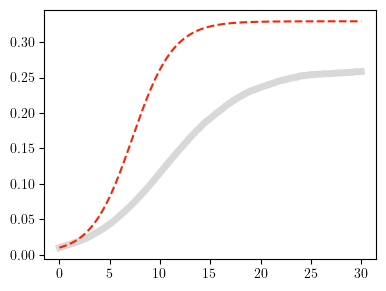

In [8]:
import numpy as np
N=1000
numits = 1000
tmax = 30
regular_graph = nx.configuration_model([10]*N)

rng = np.random.default_rng()

gamma = 1

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))


for tau in [0.15, 0.2, 0.25, 0.4]:
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    run_and_plot(regular_graph, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if tau == 0.15:
        plt.legend()
    
plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p3c.png', dpi=900)




0
100
200
300
400
500
600
700
800
900


MemoryError: Unable to allocate 7.47 GiB for an array with shape (501, 2001000) and data type float64

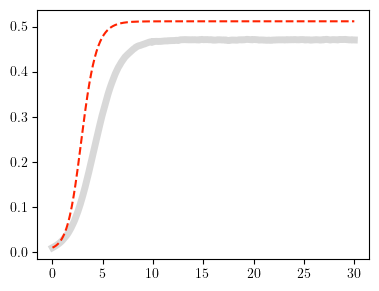

In [9]:
import numpy as np
N=1000
numits = 1000
tmax = 30

rng = np.random.default_rng()



fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))


ER = {5: nx.erdos_renyi_graph(N, 5./(N-1)), 7.5: nx.erdos_renyi_graph(N, 7.5/(N-1)),
      10: nx.erdos_renyi_graph(N, 10./(N-1))}
tau = 0.4

for kave, G in ER.items():
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    run_and_plot(G, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if kave == 5:
        plt.legend()
    
plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p3d.png', dpi=900)





0
100
200
300
400
500
600
700
800
900


MemoryError: Unable to allocate 7.47 GiB for an array with shape (501, 2001000) and data type float64

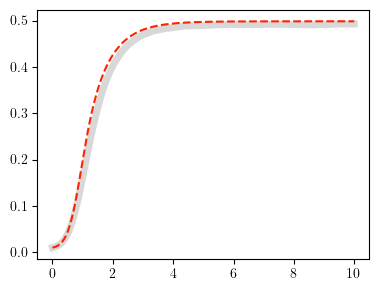

In [10]:
import numpy as np
N=1000
numits = 1000
tmax = 10

rng = np.random.default_rng()
Bimodal = {0:nx.configuration_model([4]*int(N*0.8)+[34]*int(N*0.2)), 1: nx.configuration_model([5]*int(N/2)+[15]*int(N/2))}

gamma = 1
tau = 0.25

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))

for index, G in Bimodal.items():
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    run_and_plot(G, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if index == 0:
        plt.legend()


plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p3e.png', dpi=900)




0


100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900


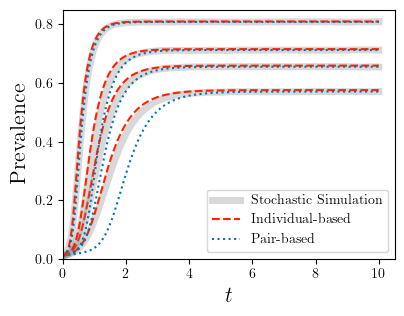

In [ ]:
import numpy as np
N=1000
numits = 1000
tmax = 10

rng = np.random.default_rng()

gamma = 1

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))



Pk = {k: 1/k**2 for k in range(7,110)}
keys = np.array(list(Pk.keys()))
weights = np.array([Pk[k] for k in keys])
weights = weights/sum(weights)
deg_dist = [1]
while sum(deg_dist)%2==1:
    deg_dist = np.random.choice(keys, size=N, replace=True, p = weights)
ScaleFree = nx.configuration_model(deg_dist)


for tau in [0.15, 0.2, 0.25, 0.4]:
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    run_and_plot(ScaleFree, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if tau == 0.15:
        plt.legend()
    
plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p3f.png', dpi=900)



# Figure 3.7


In [11]:
import networkx as nx
import EoN
from matplotlib import rc
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'

colorR = '#cd0ab3'
colorI2 = '#0073B3'


#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)



def SIR_run_and_plot(G, tau, gamma, initial_infecteds, main, inset, tmax, numits=1):
    N = G.order()
    I_all = []  # Store all report_Is arrays
    report_times = np.linspace(0,tmax,501)
    for counter in range(numits):
        if counter%100==0:
            print(counter)
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, initial_infecteds = initial_infecteds, tmax = tmax)
        I = EoN.subsample(report_times, t, I)
        I_all.append(I)
    I_mean = np.mean(I_all, axis=0)
    main.plot(report_times, I_mean/N, color='grey', linewidth=5, alpha=0.3, label = 'Stochastic Simulation')
    if inset is not None:
        inset.plot(report_times, I_mean/N, color='grey', linewidth=5, alpha=0.3, label = 'Stochastic Simulation')
    
    t, S, I, R = EoN.SIR_individual_based_pure_IC(G, tau, gamma, initial_infecteds= initial_infecteds, tmax = tmax, tcount = 501)
    main.plot(t, I/N, '--', color = colorI, label = 'Individual-based')
    if inset is not None:
        inset.plot(t, I/N, '--', color = colorI, label = 'Individual-based')

    t, S, I, R = EoN.SIR_pair_based_pure_IC(G, tau, gamma, initial_infecteds = initial_infecteds, tmax=tmax, tcount=501)
    main.plot(t, I/N, ':', color = colorI2, label = 'Pair-based')
    if inset is not None:
        inset.plot(t, I/N, ':', color = colorI2, label = 'Pair-based')
        
    if inset is not None:
        main.indicate_inset_zoom(inset, edgecolor="black")

    plt.xlabel('$t$', fontsize=16)

    plt.ylabel('Prevalence', fontsize=16)


0
100
200
300
400
500
600
700
800
900


MemoryError: 

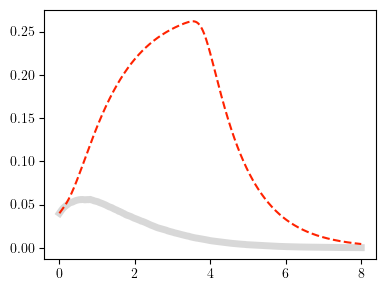

In [12]:


fig=plt.figure(0, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None 
# main.inset_axes(
#                 [.55, 0.4, 0.4, 0.4],
#                 xlim=(0, 4), ylim=(0, 0.3))

N=100
linegraph = nx.path_graph(N)

tau = 5
gamma = 1

tmax=8

initial = int(N/2)
initial_infecteds = [initial+i for i in [-2, -1, 0, 1]]

numits=1000

for tau in [5, 10]:
    SIR_run_and_plot(linegraph, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if tau == 5:
        plt.legend()
    
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.savefig('fig3p7a.png', dpi=900)
print('line done')


0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900
lattice done


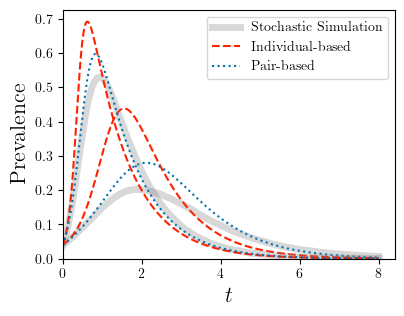

In [ ]:
gamma = 1
tmax=8
tau = 1.5
L=10
numits = 1000
lattice = nx.grid_2d_graph(L,L,periodic=False)
#print(lattice.nodes())
mid = int(L/2)
initial_infecteds = ((mid-1,mid-1),(mid-1,mid),(mid,mid-1),(mid,mid))

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])

inset = None
# main.inset_axes(
#                 [.55, 0.4, 0.4, 0.4],
#                 xlim=(0, 1), ylim=(0, 0.25))
for tau in [1.5, 4]:
    SIR_run_and_plot(lattice, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if tau == 1.5:
        plt.legend()
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.savefig('fig3p7b.png', dpi=900)

print('lattice done')

0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900


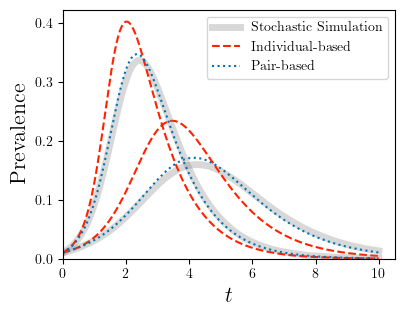

In [ ]:
import numpy as np
N=1000
numits = 1000
tmax = 10
regular_graph = nx.configuration_model([10]*N)

rng = np.random.default_rng()

gamma = 1

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))


for tau in [0.25, 0.4]:
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    SIR_run_and_plot(regular_graph, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if tau == 0.25:
        plt.legend()
    
plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p7c.png', dpi=900)


0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900


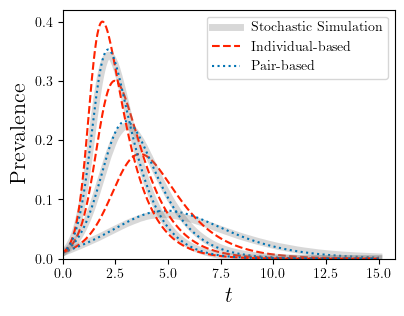

In [ ]:
import numpy as np
N=1000
numits = 1000
tmax = 15

rng = np.random.default_rng()



fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))


ER = {5: nx.erdos_renyi_graph(N, 5./(N-1)), 7.5: nx.erdos_renyi_graph(N, 7.5/(N-1)),
      10: nx.erdos_renyi_graph(N, 10./(N-1))}
tau = 0.4

for kave, G in ER.items():
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    SIR_run_and_plot(G, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if kave == 5:
        plt.legend()
    
plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p7d.png', dpi=900)



0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900


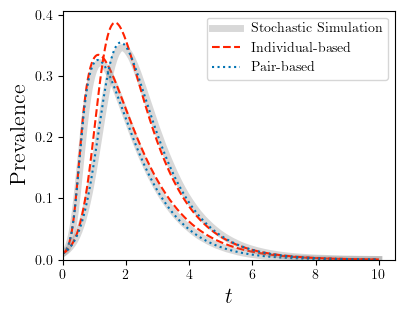

In [ ]:
import numpy as np
N=1000
numits = 1000
tmax = 10

rng = np.random.default_rng()
Bimodal = {0:nx.configuration_model([4]*int(N*0.8)+[34]*int(N*0.2)), 1: nx.configuration_model([5]*int(N/2)+[15]*int(N/2))}

gamma = 1
tau = 0.4

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))

for index, G in Bimodal.items():
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    SIR_run_and_plot(G, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if index == 0:
        plt.legend()


plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p7e.png', dpi=900)

0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900
0
100
200
300
400
500
600
700
800
900


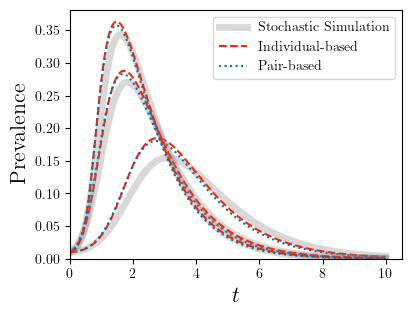

In [ ]:
import numpy as np
N=1000
numits = 1000
tmax = 10

rng = np.random.default_rng()

gamma = 1

fig=plt.figure(1, figsize= (4,3))
#plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
main = fig.add_axes([0.15,0.15,0.83, 0.83])
inset = None
#inset = main.inset_axes(
#                [.45, 0.2, 0.4, 0.3],
#                xlim=(0, 5), ylim=(0, 0.2))



Pk = {k: 1/k**2 for k in range(7,110)}
keys = np.array(list(Pk.keys()))
weights = np.array([Pk[k] for k in keys])
weights = weights/sum(weights)
deg_dist = [1]
while sum(deg_dist)%2==1:
    deg_dist = np.random.choice(keys, size=N, replace=True, p = weights)
ScaleFree = nx.configuration_model(deg_dist)


for tau in [0.1, 0.15, 0.2]:
    initial_infecteds = rng.choice(range(N), size=10, replace=False)
    SIR_run_and_plot(ScaleFree, tau, gamma, initial_infecteds, main, inset, tmax, numits)
    if tau == 0.1:
        plt.legend()
    
plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig3p7f.png', dpi=900)
